In [1]:
import geopandas as gpd
import pandas as pd
from pysits import *
import os

In [2]:
# lê o gpkg, reprojeta pra WGS84, renomeia e adiciona colunas de data
amostras_sf = (
    gpd.read_file("/home/jovyan/SR_agricola/feijao/dados/pontos_feijao.gpkg")
    .to_crs(epsg=4326)
    .rename(columns={"Class_s": "label"})
)

amostras_sf["start_date"] = pd.to_datetime("2023-09-30")  # ajuste ao início real da safra de feijão
amostras_sf["end_date"] = pd.to_datetime("2024-09-29")    # ajuste ao fim real do ciclo

# mantém só o essencial + geometria
amostras_sf = amostras_sf[["label", "start_date", "end_date", "geometry"]]


# extrai coordenadas
lon_max = amostras_sf.geometry.x.max()
lon_min = amostras_sf.geometry.x.min()
lat_max = amostras_sf.geometry.y.max()
lat_min = amostras_sf.geometry.y.min()

# define o roi para os dados de feijão
roi = {
    "lat_max": lat_max,
    "lat_min": lat_min,
    "lon_max": lon_max,
    "lon_min": lon_min,
}

# trocando as classes que nao sao feijao para 'outro'
amostras_sf.loc[amostras_sf["label"] != 'Feijao', 'label'] = 'outro'

amostras_sf["longitude"] = amostras_sf.geometry.x
amostras_sf["latitude"] = amostras_sf.geometry.y

amostras_sf

,label,start_date,end_date,geometry,longitude,latitude
0,outro,2023-09-30,2024-09-29,POINT (-53.22025 -25.8105),-53.220254,-25.810503
1,outro,2023-09-30,2024-09-29,POINT (-53.09439 -25.7709),-53.094391,-25.770897
2,outro,2023-09-30,2024-09-29,POINT (-53.09101 -25.66478),-53.091011,-25.664784
3,outro,2023-09-30,2024-09-29,POINT (-53.22025 -25.8105),-53.220254,-25.810503
4,outro,2023-09-30,2024-09-29,POINT (-53.09439 -25.7709),-53.094391,-25.770897
...,...,...,...,...,...,...
325,outro,2023-09-30,2024-09-29,POINT (-53.11905 -25.8947),-53.119050,-25.894695
326,outro,2023-09-30,2024-09-29,POINT (-53.13041 -25.8485),-53.130408,-25.848504
327,outro,2023-09-30,2024-09-29,POINT (-53.19488 -25.80942),-53.194877,-25.809424
328,outro,2023-09-30,2024-09-29,POINT (-53.1611 -26.06415),-53.161100,-26.064150


numero de pontos:  330
     label start_date   end_date                     geometry  longitude  \
0    outro 2023-09-30 2024-09-29   POINT (-53.22025 -25.8105) -53.220254   
1    outro 2023-09-30 2024-09-29   POINT (-53.09439 -25.7709) -53.094391   
2    outro 2023-09-30 2024-09-29  POINT (-53.09101 -25.66478) -53.091011   
3    outro 2023-09-30 2024-09-29   POINT (-53.22025 -25.8105) -53.220254   
4    outro 2023-09-30 2024-09-29   POINT (-53.09439 -25.7709) -53.094391   
..     ...        ...        ...                          ...        ...   
325  outro 2023-09-30 2024-09-29   POINT (-53.11905 -25.8947) -53.119050   
326  outro 2023-09-30 2024-09-29   POINT (-53.13041 -25.8485) -53.130408   
327  outro 2023-09-30 2024-09-29  POINT (-53.19488 -25.80942) -53.194877   
328  outro 2023-09-30 2024-09-29   POINT (-53.1611 -26.06415) -53.161100   
329  outro 2023-09-30 2024-09-29   POINT (-53.39732 -25.9283) -53.397325   

      latitude  
0   -25.810503  
1   -25.770897  
2   -25.66478

<Axes: >

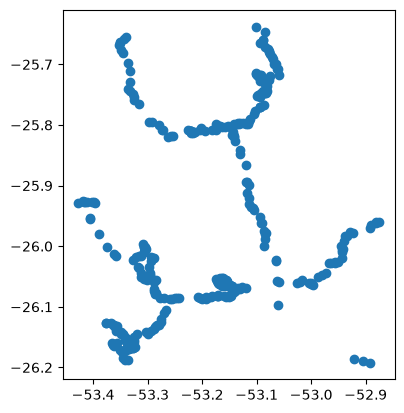

In [3]:
print("numero de pontos: ", len(amostras_sf))
print(amostras_sf)
amostras_sf.plot()

In [4]:
roi

{'lat_max': np.float64(-25.63763272049445),
 'lat_min': np.float64(-26.192046131772535),
 'lon_max': np.float64(-52.874602297626225),
 'lon_min': np.float64(-53.428003492965175)}

In [5]:
sits_list_collections()

AWS:
- SENTINEL-2-L2A (SENTINEL-2/MSI)
- grid system: MGRS
- period: 2015 to now
- bands: B01 B02 B03 B04 B05 B06 B07 B08 B8A B09 B11 B12 CLOUD
- opendata collection 

- SENTINEL-S2-L2A-COGS (SENTINEL-2/MSI)
- grid system: MGRS
- period: 2015 to now
- bands: B01 B02 B03 B04 B05 B06 B07 B08 B8A B09 B11 B12 CLOUD
- opendata collection 

- LANDSAT-C2-L2 (LANDSAT/TM-ETM-OLI)
- grid system: WRS-2
- period: 1982 to now
- bands: BLUE GREEN RED NIR08 SWIR16 SWIR22 CLOUD
- not opendata collection

BDC:
- CBERS-WFI-16D (CBERS-4/WFI)
- grid system: BDC-Large V2
- period: 2016 to 2024
- bands: NDVI EVI B13 B14 B15 B16 CLOUD
- opendata collection (requires access token)

- CBERS-WFI-8D (CBERS-4-4A/WFI)
- grid system: BDC-Large V2
- period: 2020 to 2024
- bands: NDVI EVI B13 B14 B15 B16 CLOUD
- opendata collection (requires access token)

- CBERS-MUX-2M (CBERS-4/MUX)
- grid system: BDC-Medium V2
- period: 2016 to 2024
- bands: NDVI EVI B05 B06 B07 B08 CLOUD
- opendata collection (requires access tok

In [6]:
# Define a data cube in the BDC repository based on the LEM ROI
bdc_cube = sits_cube(
    source = "BDC", 
    collection  = "SENTINEL-2-16D",
    bands = ("NDVI", "EVI", "B02", "B03", "B04", "B08", "B8A", "B05", "B06", "B07", "B11", "B12"),
    roi = roi,
    start_date = "2023-09-30",
    end_date = "2024-09-29"
)

  |======================================================================| 100%


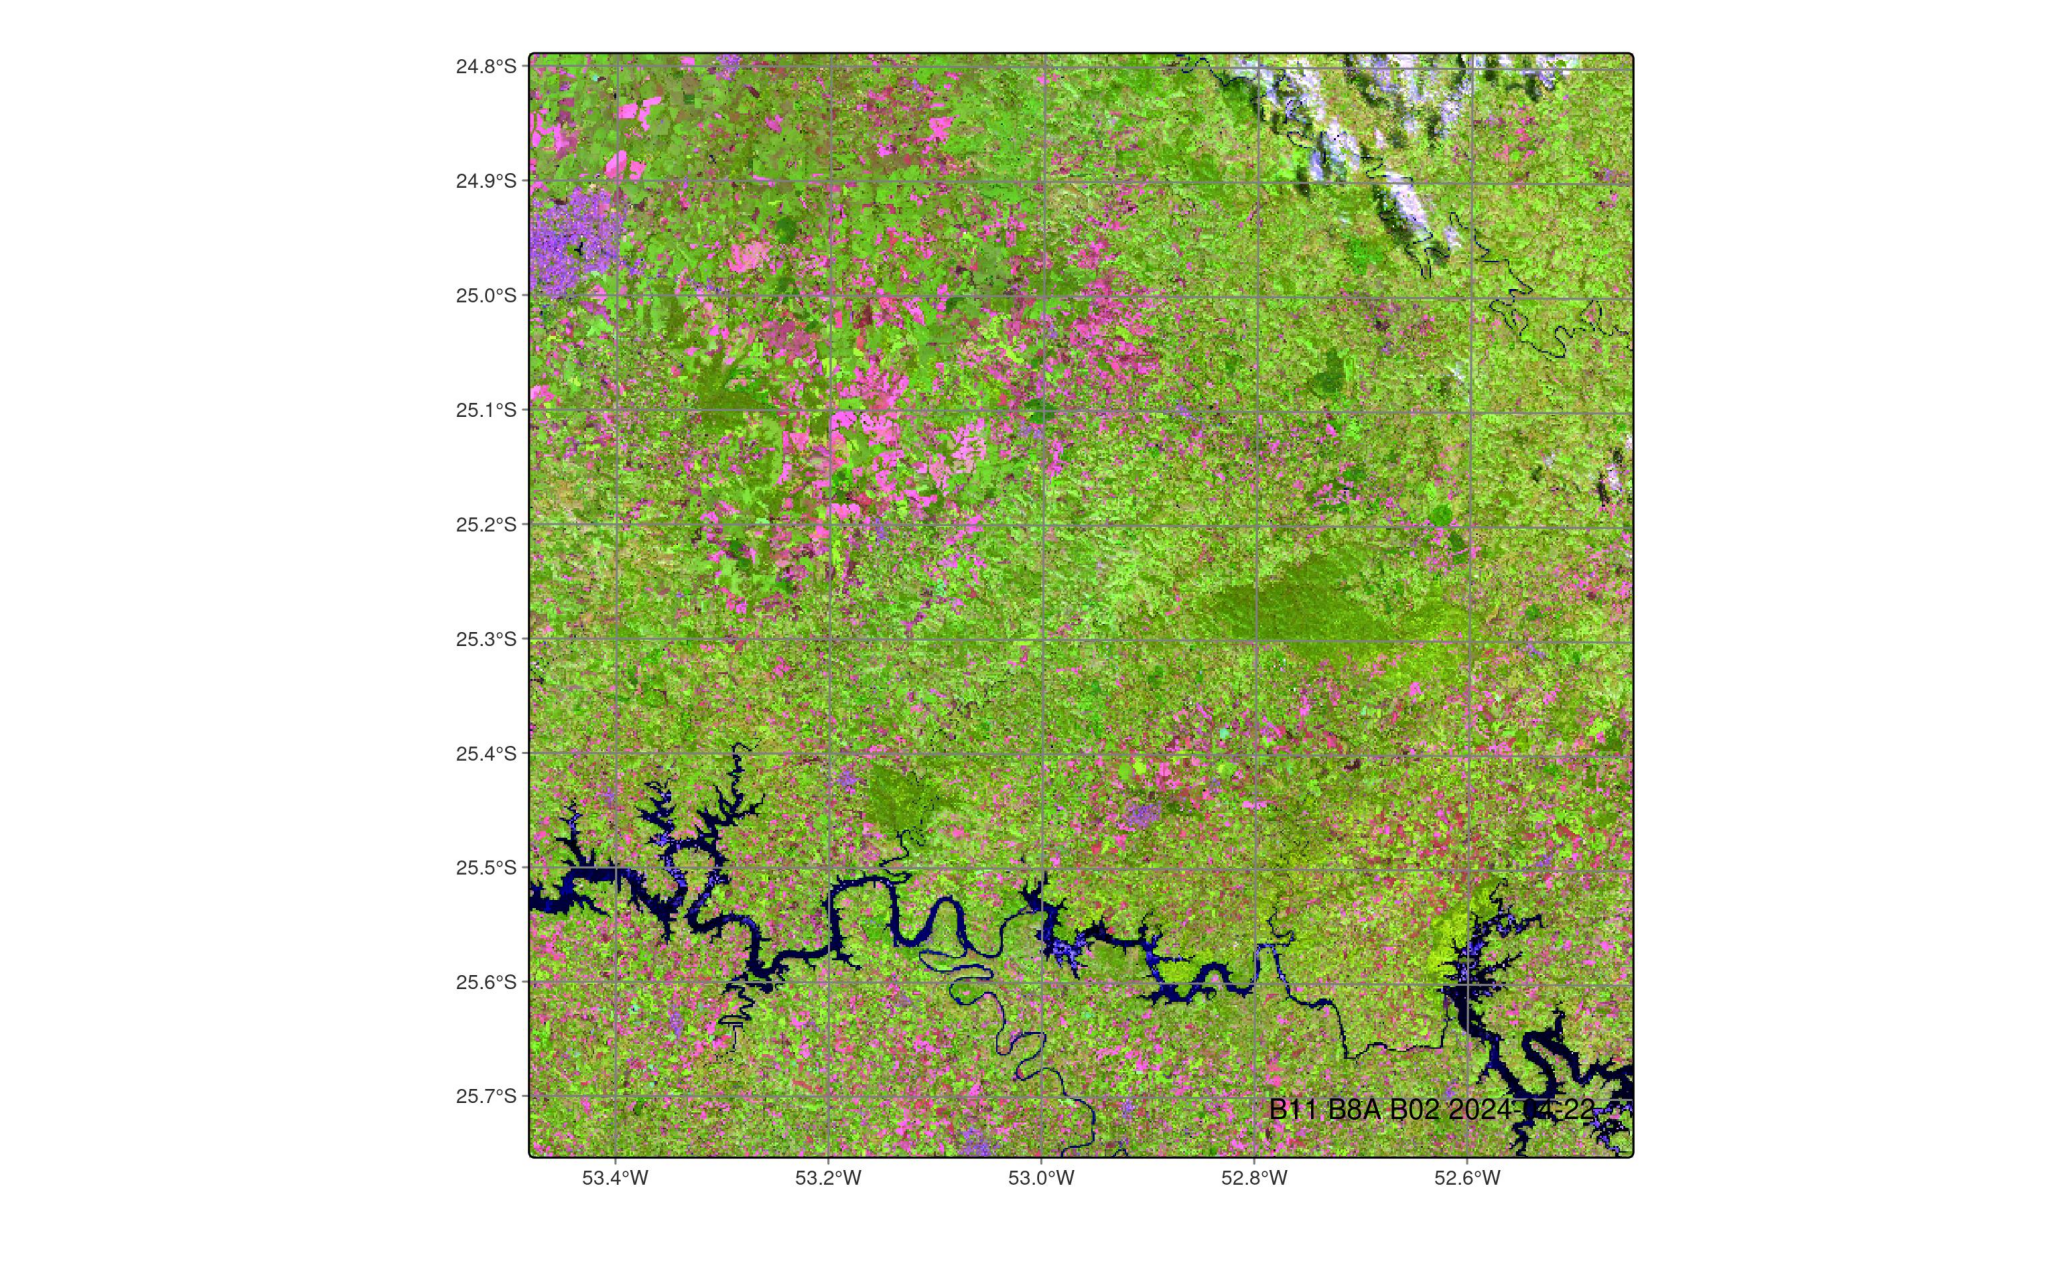

In [9]:
# Plot one temporal instance
plot(bdc_cube, red = "B11", green = "B8A", blue = "B02")

In [7]:
amostras_sem_geom = amostras_sf.drop(columns=['geometry'])

samples = sits_get_data(
    cube=bdc_cube,
    samples=amostras_sem_geom
)

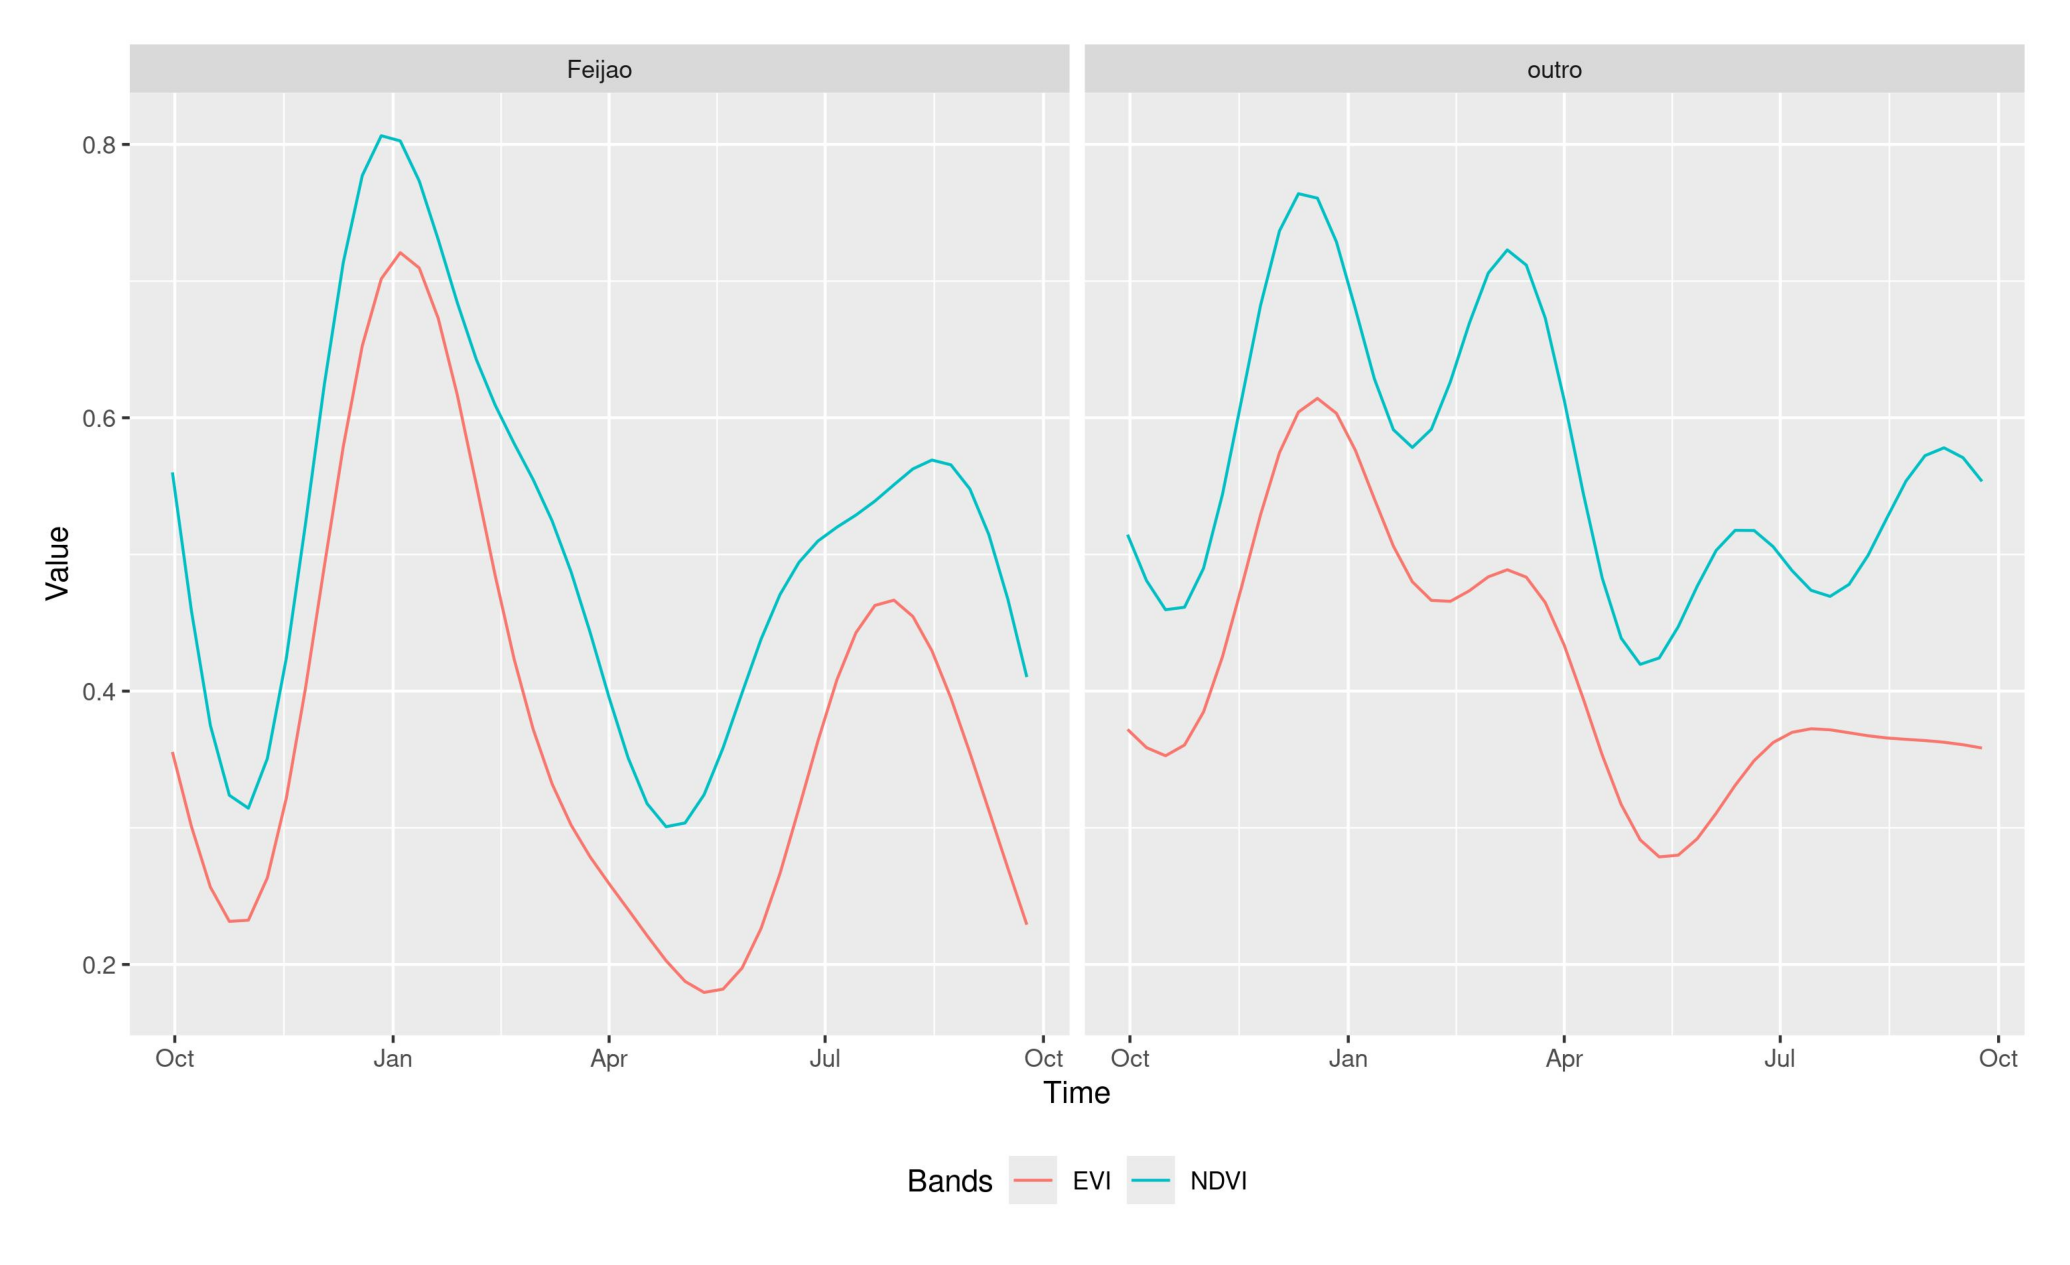

In [8]:
# Generate the temporal patterns
plot(
    sits_patterns(
        sits_select(samples, bands = ("NDVI", "EVI"))
    )
)

In [15]:
samples

,longitude,latitude,start_date,end_date,label,cube,time_series
0,-53.428003,-25.928433,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 B05...
1,-53.417895,-25.925936,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 B05...
2,-53.417471,-25.927336,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 B05...
3,-53.414426,-25.926993,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 B05...
4,-53.410252,-25.927242,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 ...
...,...,...,...,...,...,...,...
319,-52.891632,-26.192046,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 B05...
320,-52.890236,-25.965720,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 B05...
321,-52.881340,-25.962469,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 B05...
322,-52.880096,-25.960324,2023-09-30,2024-09-29,outro,SENTINEL-2-16D,Index B02 B03 B04 B05...


# treinando o modelo

In [19]:
summary(samples)

,label,count,prop
1,Feijao,44,0.135802
2,outro,280,0.864198


  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%


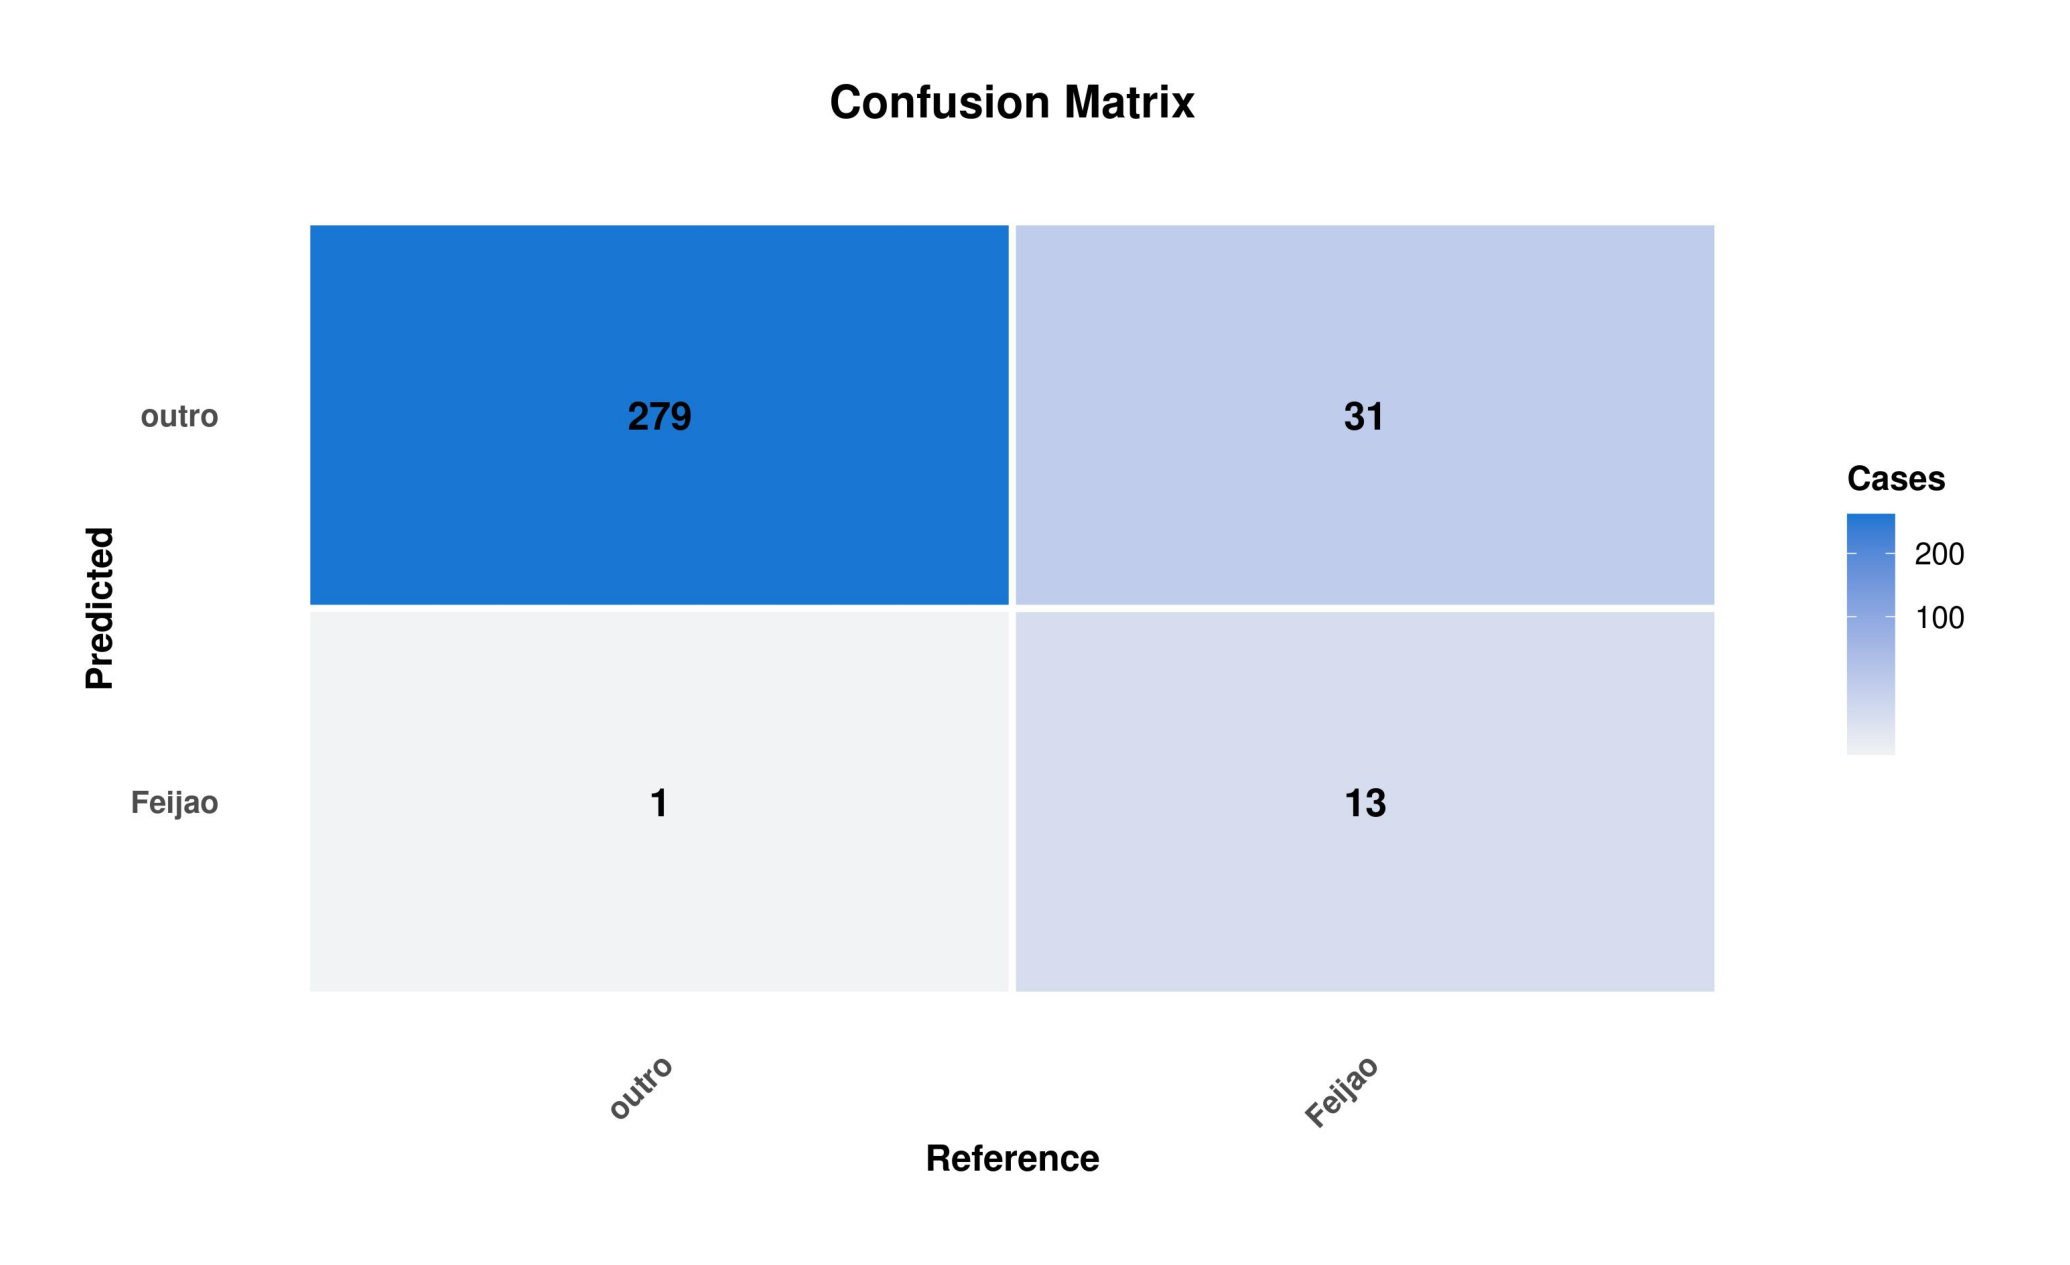

In [18]:
rfor_validate_mt = sits_kfold_validate(
    samples = samples,
    folds = 5,
    ml_method = sits_rfor(),
    multicores = 5
)
# plot the confusion matrix
plot(rfor_validate_mt, type_ = "confusion_matrix")

In [20]:
samples_balanced = sits_reduce_imbalance(
    samples,
    n_samples_over = 50,
    n_samples_under = 80
)

summary(samples_balanced)

,label,count,prop
1,Feijao,50,0.333333
2,outro,100,0.666667


  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%


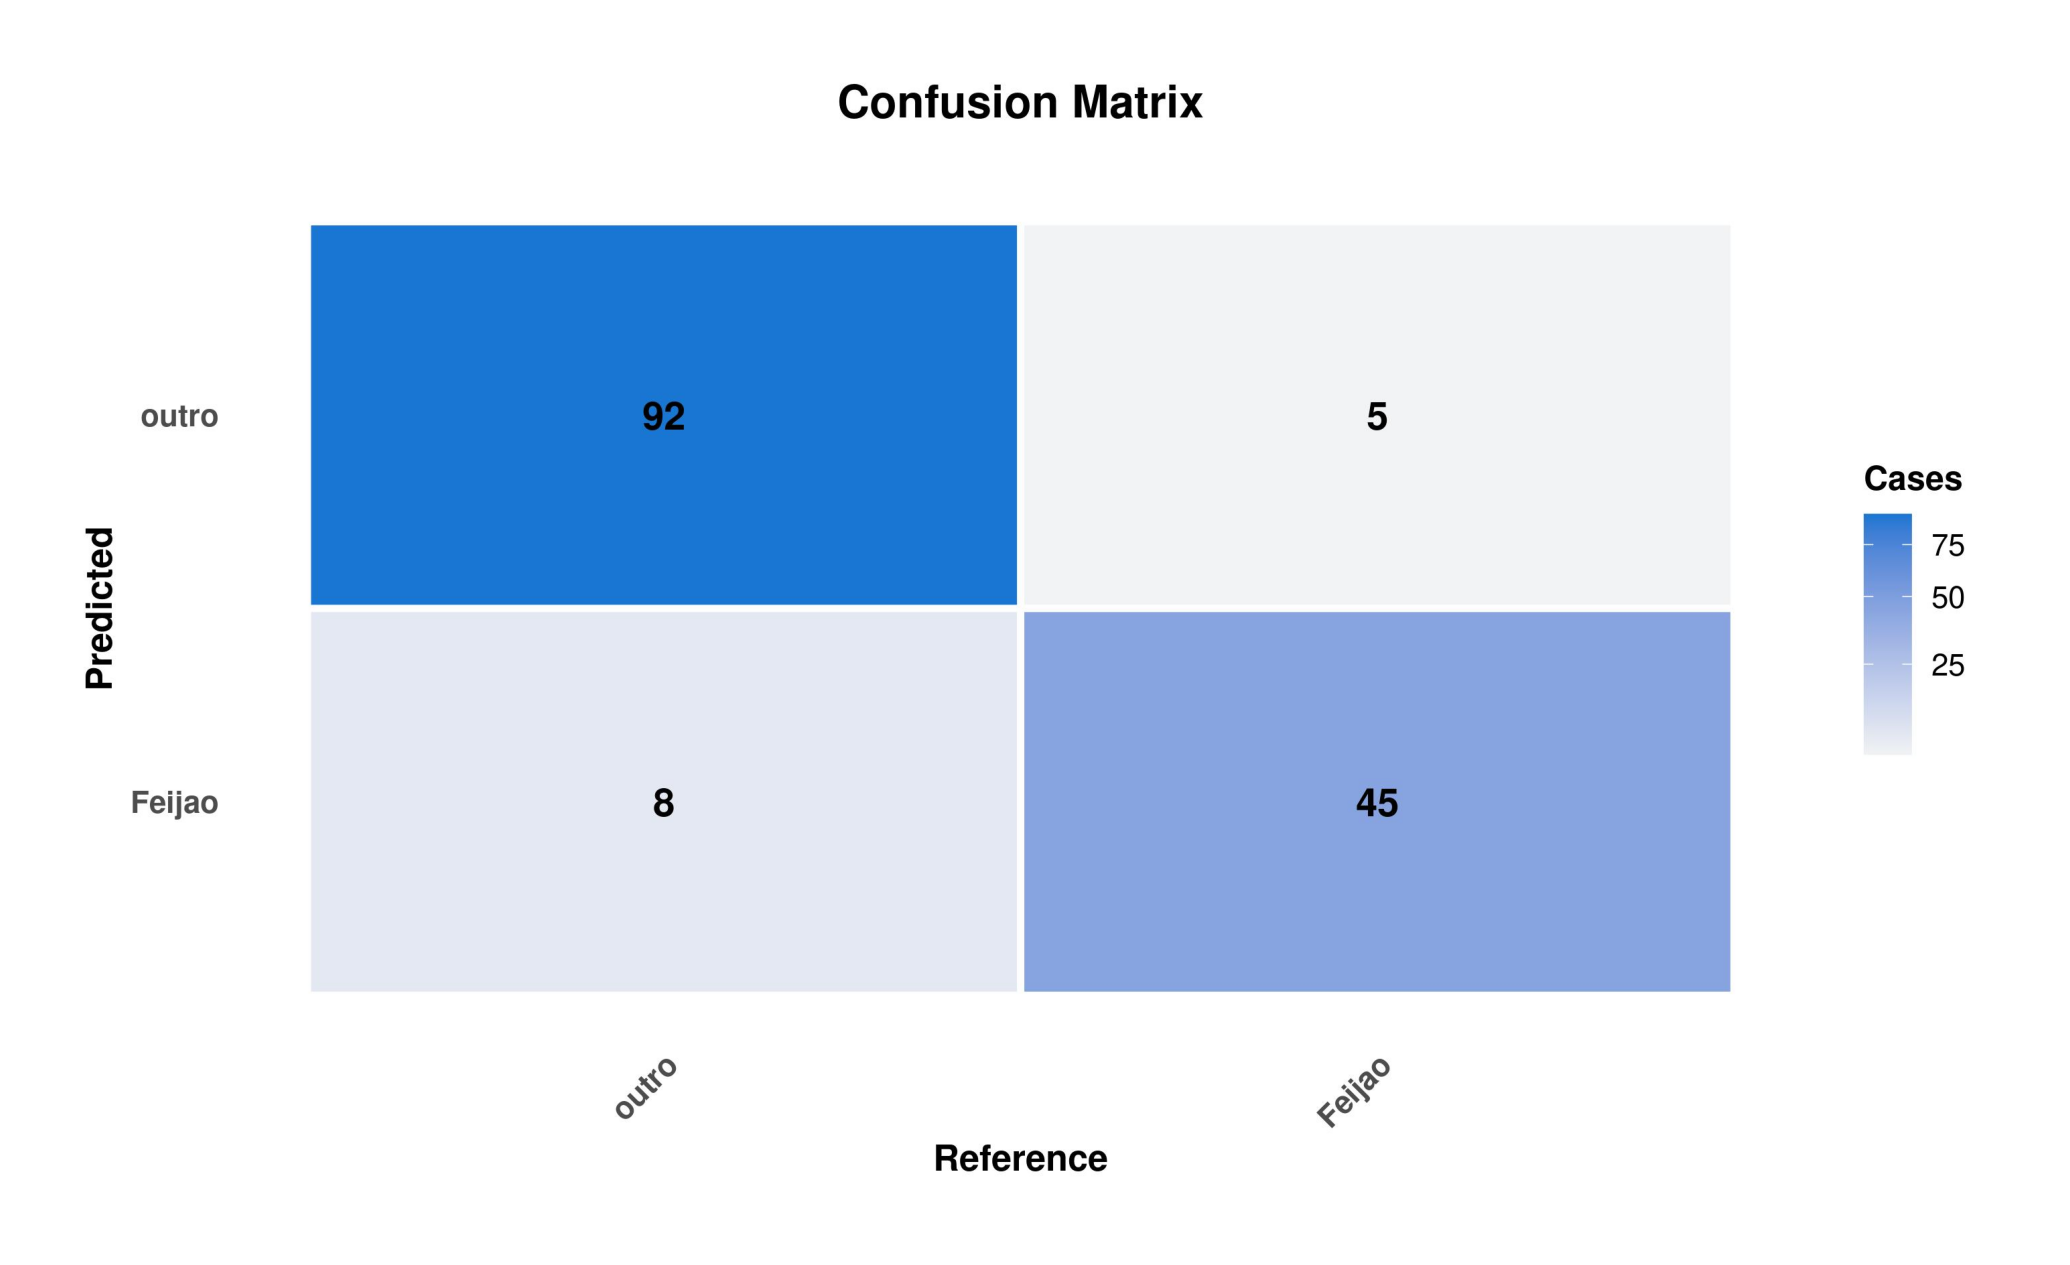

In [21]:
rfor_validate_balanced = sits_kfold_validate(
    samples = samples_balanced,
    folds = 5,
    ml_method = sits_rfor(),
    multicores = 5
)
# plot the confusion matrix
plot(rfor_validate_balanced, type_ = "confusion_matrix")

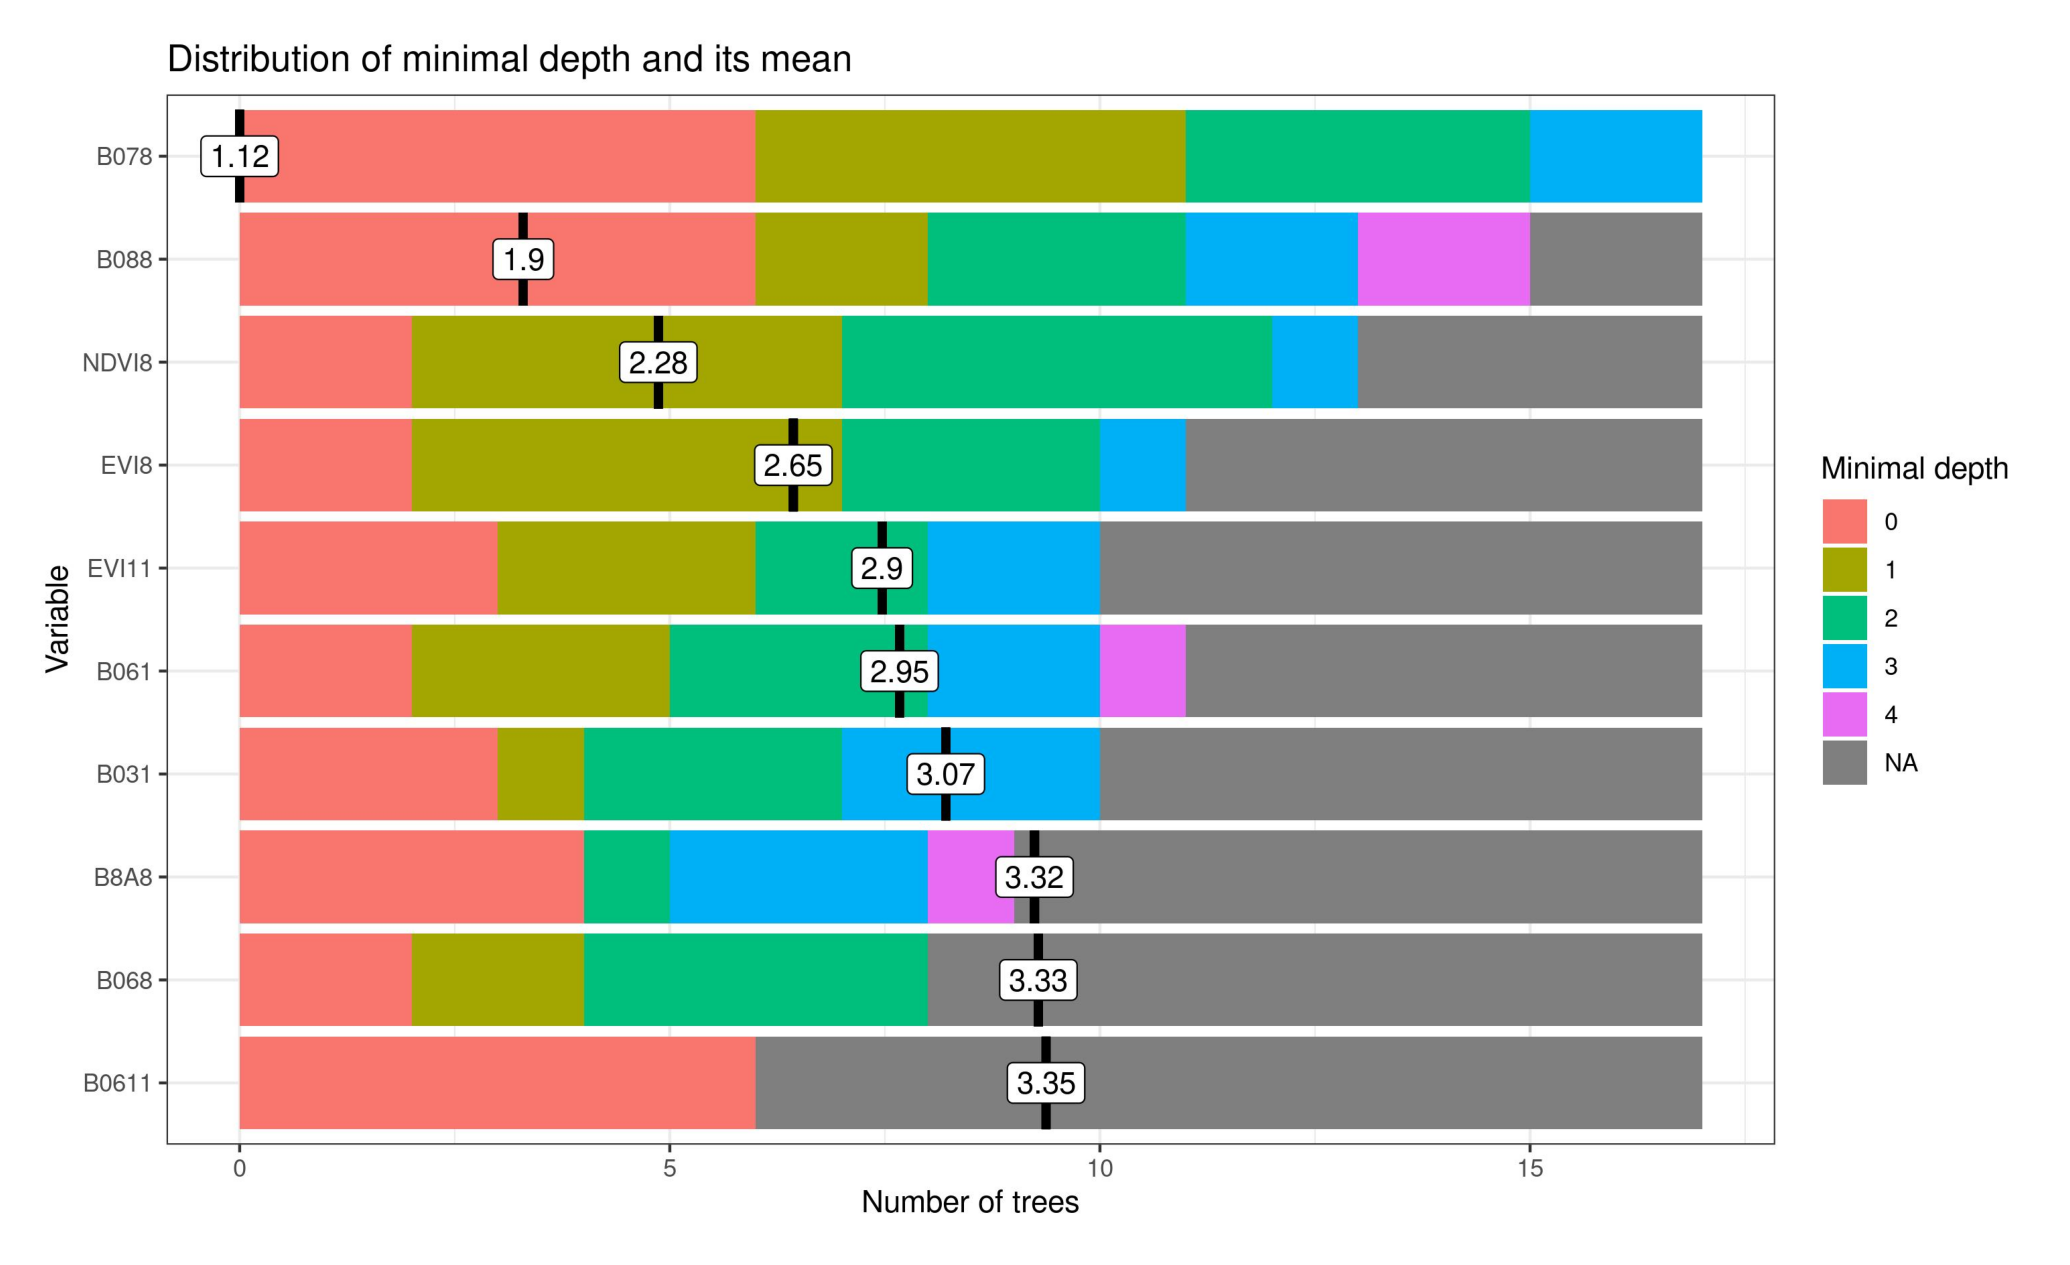

In [30]:
# Train the Mato Grosso samples with Random Forest algorithm
rfor_model = sits_train(
    samples = samples_balanced, 
    ml_method = sits_rfor(num_trees = 100))

# Plot the most important variables of the model
plot(rfor_model)

In [28]:
print(rfor_validate_balanced)

Confusion Matrix and Statistics

          Reference
Prediction outro Feijao
    outro     92      5
    Feijao     8     45
                                     
         Accuracy : 0.9133           
           95% CI : ( 0.8564, 0.953 )
                                     
            Kappa : 0.8079           
                                     
  Prod Acc  outro : 0.9200           
 Prod Acc  Feijao : 0.9000           
  User Acc  outro : 0.9485           
 User Acc  Feijao : 0.8491           
                                     

